# ☀️ SolarStore AI — Phase 4: Solar Forecasting Models

**Goal:** Build and evaluate two solar irradiance forecasting models:
- **XGBoost** — strong tabular ML baseline (fast, interpretable, SHAP explainability)
- **LSTM** — deep learning model that learns sequential/seasonal patterns

## Why two models?
XGBoost is our baseline — it is fast to train, easy to explain, and often competitive.
LSTM captures temporal dependencies that XGBoost cannot (e.g. irradiance today depends on yesterday).
We compare both and use the better one in the Streamlit app.

## Sections
1. Imports & Setup
2. Load & Prepare Data
3. Feature Engineering
4. Train/Test Split (time-series aware)
5. XGBoost Baseline
6. XGBoost SHAP Explainability
7. LSTM Data Preparation
8. LSTM Model (Keras)
9. Model Comparison
10. Save Models
11. Key Findings


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import joblib
import os

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"]     = 120

os.makedirs("../models", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

print("Libraries loaded")
print(f"XGBoost version: {xgb.__version__}")

Libraries loaded
XGBoost version: 3.2.0


In [3]:
df = pd.read_csv("data/raw/all_cities_solar_data.csv", parse_dates=["date"])

print(f"Shape: {df.shape}")
print(f"Cities: {df['city'].nunique()}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()

Shape: (34713, 11)
Cities: 19
Date range: 2020-01-01 to 2024-12-31


,date,city,state,zone,solar_irradiance_kwh_m2_day,clear_sky_irradiance_kwh_m2_day,temperature_2m_c,humidity_pct,cloud_cover_pct,wind_speed_2m_ms,precipitation_mm_day
0,2020-01-01,Lagos,Lagos,South West,3.768,4.604,33.05,22.4,31.3,3.15,0.01
1,2020-01-02,Lagos,Lagos,South West,3.349,4.236,28.95,20.0,45.1,2.11,0.07
2,2020-01-03,Lagos,Lagos,South West,2.608,4.106,30.63,20.0,26.3,1.38,0.06
3,2020-01-04,Lagos,Lagos,South West,2.976,5.178,30.79,26.0,40.2,2.73,0.02
4,2020-01-05,Lagos,Lagos,South West,3.191,4.229,33.70,24.6,29.5,1.91,0.00


In [4]:
# ─────────────────────────────────────────────────────────────
# FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────
# WHY THIS STEP MATTERS:
# Raw columns (date, city, zone) are not useful to a model.
# We need to convert them into NUMERIC signals the model can learn from.
#
# Three types of features we engineer:
#   1. TIME features    — capture seasonality and trends
#   2. LAG features     — capture autocorrelation (yesterday predicts today)
#   3. ROLLING features — capture local weather patterns (7-day avg)

df = df.sort_values(["city", "date"]).reset_index(drop=True)

# ── 1. Time features ──────────────────────────────────────────
df["month"]        = df["date"].dt.month
df["day_of_year"]  = df["date"].dt.dayofyear
df["week"]         = df["date"].dt.isocalendar().week.astype(int)
df["quarter"]      = df["date"].dt.quarter
df["year"]         = df["date"].dt.year

# Cyclical encoding of month and day_of_year
# WHY CYCLICAL: Month 12 and Month 1 are close (both winter)
# but numerically they are far apart (12 vs 1).
# Sine/cosine encoding fixes this — they wrap around correctly.
df["month_sin"]   = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"]   = np.cos(2 * np.pi * df["month"] / 12)
df["doy_sin"]     = np.sin(2 * np.pi * df["day_of_year"] / 365)
df["doy_cos"]     = np.cos(2 * np.pi * df["day_of_year"] / 365)

# ── 2. Lag features ───────────────────────────────────────────
# Lag 1: yesterday's irradiance
# Lag 7: same day last week
# Lag 30: same day last month
# These give the model memory of recent weather patterns.
for lag in [1, 2, 3, 7, 14, 30]:
    df[f"irr_lag_{lag}"] = (
        df.groupby("city")["solar_irradiance_kwh_m2_day"]
        .shift(lag)
    )

# ── 3. Rolling window features ────────────────────────────────
# Rolling 7-day and 30-day means of irradiance and cloud cover
for window in [7, 14, 30]:
    df[f"irr_roll_{window}d"] = (
        df.groupby("city")["solar_irradiance_kwh_m2_day"]
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )
    df[f"cloud_roll_{window}d"] = (
        df.groupby("city")["cloud_cover_pct"]
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )

# ── 4. Encode categorical features ────────────────────────────
# XGBoost needs numbers — encode city and zone as integers
le_city = LabelEncoder()
le_zone = LabelEncoder()
df["city_enc"] = le_city.fit_transform(df["city"])
df["zone_enc"] = le_zone.fit_transform(df["zone"])

# ── 5. Drop rows with NaN from lag features ───────────────────
df = df.dropna().reset_index(drop=True)

print(f"Shape after feature engineering: {df.shape}")
print(f"New features: {[c for c in df.columns if any(x in c for x in ['lag','roll','sin','cos','enc'])]}")

Shape after feature engineering: (34143, 34)
New features: ['month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'irr_lag_1', 'irr_lag_2', 'irr_lag_3', 'irr_lag_7', 'irr_lag_14', 'irr_lag_30', 'irr_roll_7d', 'cloud_roll_7d', 'irr_roll_14d', 'cloud_roll_14d', 'irr_roll_30d', 'cloud_roll_30d', 'city_enc', 'zone_enc']


In [5]:
# ─────────────────────────────────────────────────────────────
# TRAIN / TEST SPLIT — TIME-SERIES AWARE
# ─────────────────────────────────────────────────────────────
# CRITICAL LEARNING POINT:
# You CANNOT use random train/test split for time-series data.
# Why? Because if test data is scattered throughout the timeline,
# the model has seen future data during training → data leakage.
# The result looks great in evaluation but fails in production.
#
# Correct approach: CHRONOLOGICAL SPLIT
# Train on earlier dates, test on later dates.
# We use 2020-2023 for training, 2024 for testing.

TRAIN_END = "2023-12-31"
TEST_START = "2024-01-01"

FEATURE_COLS = [
    # Weather features
    "clear_sky_irradiance_kwh_m2_day",
    "temperature_2m_c", "humidity_pct",
    "cloud_cover_pct", "wind_speed_2m_ms",
    "precipitation_mm_day",
    # Time features
    "month", "day_of_year", "quarter", "year",
    "month_sin", "month_cos", "doy_sin", "doy_cos",
    # Lag features
    "irr_lag_1", "irr_lag_2", "irr_lag_3",
    "irr_lag_7", "irr_lag_14", "irr_lag_30",
    # Rolling features
    "irr_roll_7d", "irr_roll_14d", "irr_roll_30d",
    "cloud_roll_7d", "cloud_roll_14d", "cloud_roll_30d",
    # Location features
    "city_enc", "zone_enc",
]

TARGET = "solar_irradiance_kwh_m2_day"

train = df[df["date"] <= TRAIN_END]
test  = df[df["date"] >= TEST_START]

X_train = train[FEATURE_COLS]
y_train = train[TARGET]
X_test  = test[FEATURE_COLS]
y_test  = test[TARGET]

print(f"Train: {X_train.shape}  ({train['date'].min().date()} to {train['date'].max().date()})")
print(f"Test:  {X_test.shape}   ({test['date'].min().date()} to {test['date'].max().date()})")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Target:   {TARGET}")

Train: (27189, 28)  (2020-01-31 to 2023-12-31)
Test:  (6954, 28)   (2024-01-01 to 2024-12-31)
Features: 28
Target:   solar_irradiance_kwh_m2_day


Training XGBoost...

XGBoost Results:
  RMSE : 0.4301 kWh/m2/day
  MAE  : 0.3422 kWh/m2/day
  R2   : 0.8877


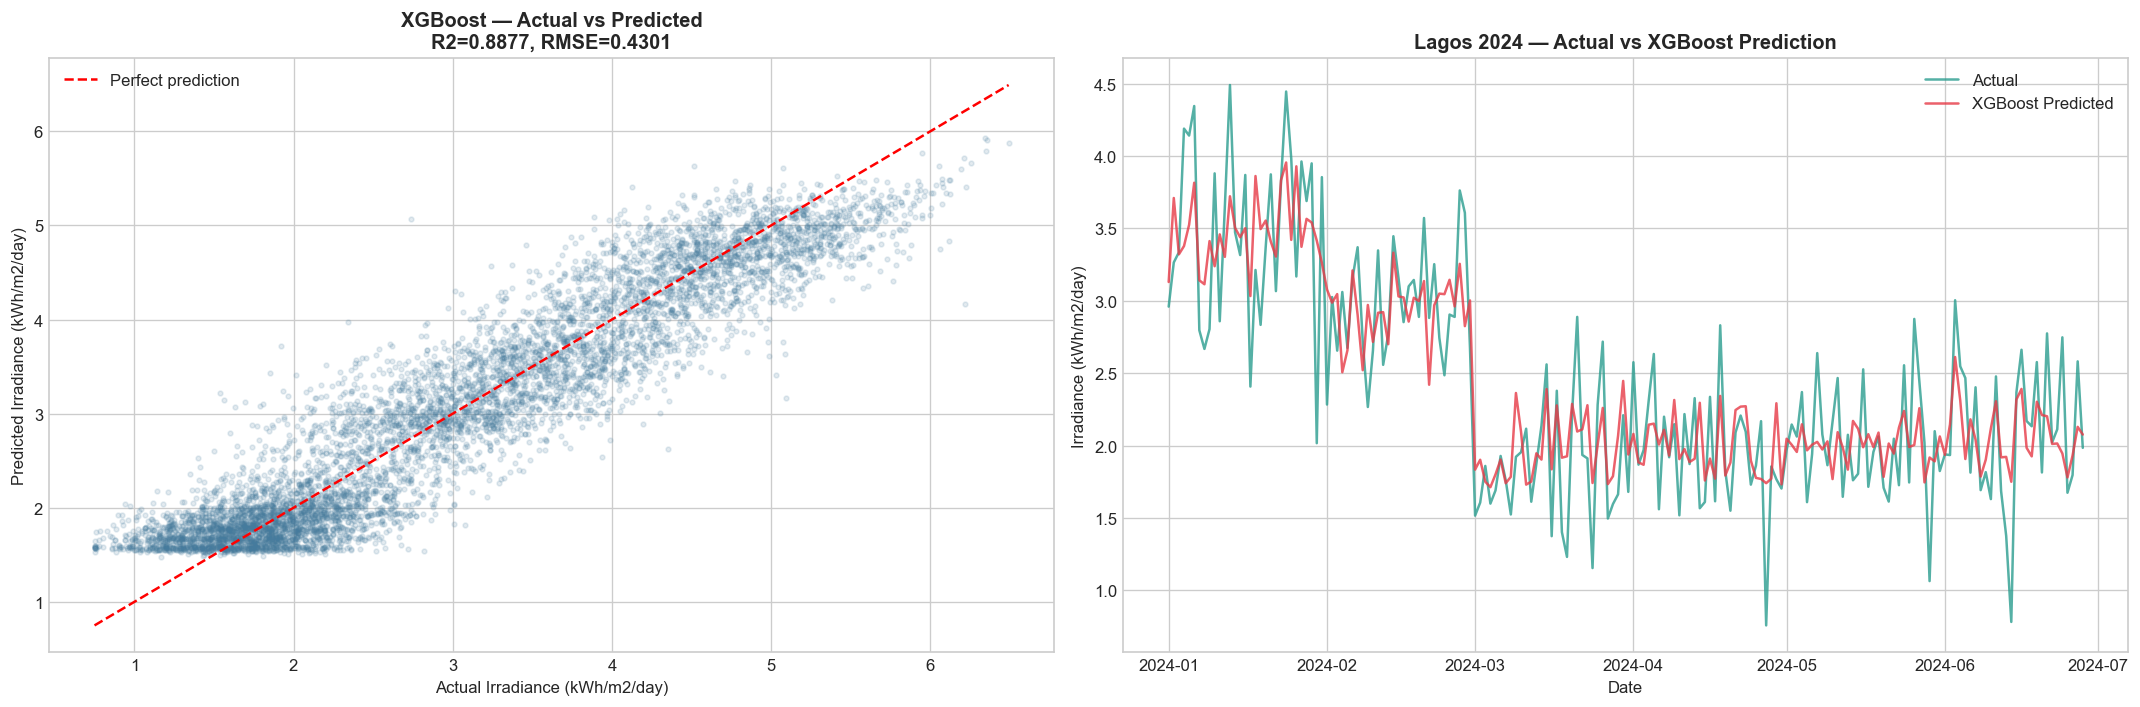

In [8]:
# ─────────────────────────────────────────────────────────────
# MODEL 1 — XGBoost Baseline
# ─────────────────────────────────────────────────────────────
# WHY XGBOOST FIRST?
# XGBoost (Extreme Gradient Boosting) is the gold standard for
# tabular data. It builds an ensemble of decision trees where
# each tree corrects the errors of the previous one.
#
# KEY HYPERPARAMETERS:
#   n_estimators   → number of trees (more = slower but better)
#   max_depth      → how deep each tree grows (deeper = more complex)
#   learning_rate  → how much each tree contributes (lower = more trees needed)
#   subsample      → fraction of data per tree (prevents overfitting)
#   colsample      → fraction of features per tree (prevents overfitting)

xgb_model = xgb.XGBRegressor(
    n_estimators    = 500,
    max_depth       = 6,
    learning_rate   = 0.05,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    min_child_weight= 3,
    reg_alpha       = 0.1,   # L1 regularization
    reg_lambda      = 1.0,   # L2 regularization
    random_state    = 42,
    n_jobs          = -1,    # use all CPU cores
    early_stopping_rounds = 20,
    eval_metric     = "rmse",
    verbosity       = 0,
)

print("Training XGBoost...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

y_pred_xgb = xgb_model.predict(X_test)

# ── Evaluation metrics ────────────────────────────────────────
# RMSE: Root Mean Squared Error — penalizes large errors more
# MAE:  Mean Absolute Error — average magnitude of errors
# R²:   Coefficient of determination — 1.0 = perfect fit
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)

print("\nXGBoost Results:")
print(f"  RMSE : {rmse_xgb:.4f} kWh/m2/day")
print(f"  MAE  : {mae_xgb:.4f} kWh/m2/day")
print(f"  R2   : {r2_xgb:.4f}")

# ── Plot: Actual vs Predicted ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Scatter: perfect model = diagonal line
axes[0].scatter(y_test, y_pred_xgb, alpha=0.15, s=8, color="#457B9D")
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Irradiance (kWh/m2/day)")
axes[0].set_ylabel("Predicted Irradiance (kWh/m2/day)")
axes[0].set_title(f"XGBoost — Actual vs Predicted\nR2={r2_xgb:.4f}, RMSE={rmse_xgb:.4f}", fontweight="bold")
axes[0].legend()

# Time series: first 180 days of test set for one city
city_test = test[test["city"] == "Lagos"].copy()
city_pred = y_pred_xgb[test["city"] == "Lagos"]
axes[1].plot(city_test["date"].values[:180], city_test[TARGET].values[:180],
             color="#2A9D8F", linewidth=1.5, label="Actual", alpha=0.8)
axes[1].plot(city_test["date"].values[:180], city_pred[:180],
             color="#E63946", linewidth=1.5, label="XGBoost Predicted", alpha=0.8)
axes[1].set_title("Lagos 2024 — Actual vs XGBoost Prediction", fontweight="bold")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Irradiance (kWh/m2/day)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/16_xgboost_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

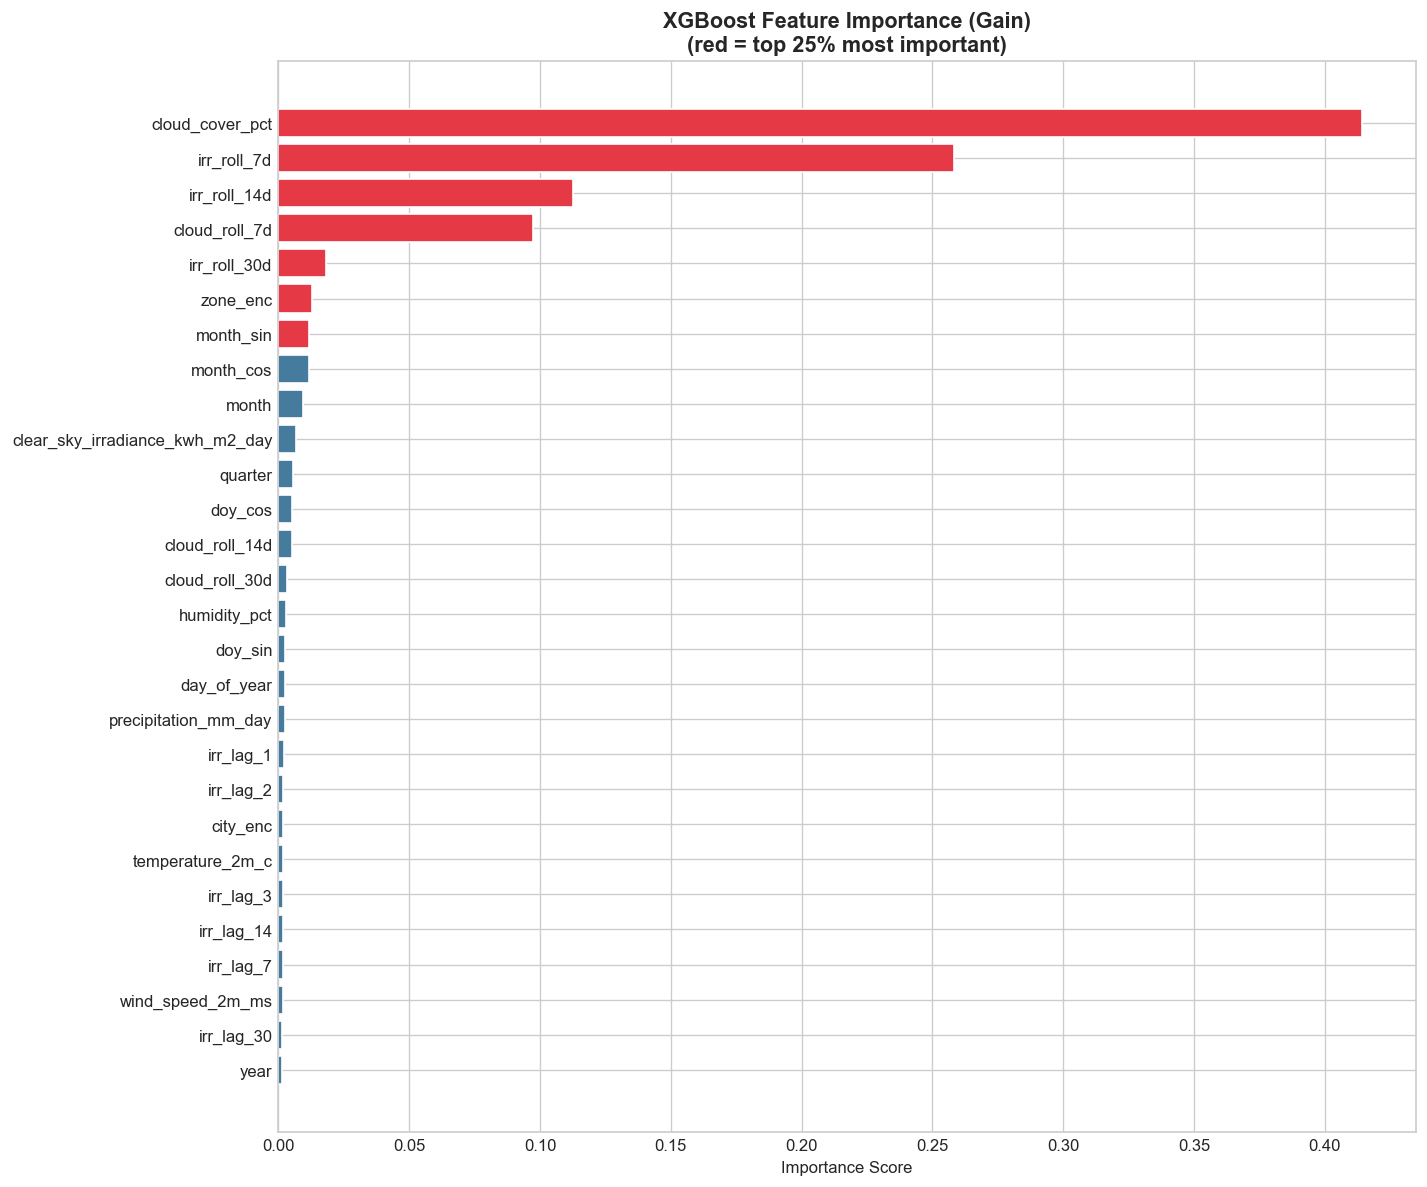


Top 10 most important features:
                        feature  importance
                cloud_cover_pct    0.414130
                    irr_roll_7d    0.258169
                   irr_roll_14d    0.112617
                  cloud_roll_7d    0.097500
                   irr_roll_30d    0.018110
                       zone_enc    0.012744
                      month_sin    0.011812
                      month_cos    0.011638
                          month    0.009361
clear_sky_irradiance_kwh_m2_day    0.006747


In [10]:
# ─────────────────────────────────────────────────────────────
# XGBOOST — Feature Importance
# ─────────────────────────────────────────────────────────────
# WHY FEATURE IMPORTANCE MATTERS:
# It tells you WHICH inputs the model relies on most.
# This validates your feature engineering and gives
# explainability — critical for presenting to stakeholders.
#
# Two types:
#   weight     → how many times a feature is used in splits
#   gain       → average improvement in loss when feature is used
#   gain is more meaningful — use this one

importance = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
colors = ["#E63946" if imp > importance["importance"].quantile(0.75)
          else "#457B9D" for imp in importance["importance"]]
ax.barh(importance["feature"], importance["importance"],
        color=colors, edgecolor="white")
ax.set_title("XGBoost Feature Importance (Gain)\n"
             "(red = top 25% most important)",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("../data/processed/17_xgboost_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 most important features:")
print(importance.tail(10)[["feature","importance"]].sort_values("importance", ascending=False).to_string(index=False))

In [11]:
# ─────────────────────────────────────────────────────────────
# MODEL 2 — LSTM (Long Short-Term Memory)
# ─────────────────────────────────────────────────────────────
# WHY LSTM FOR SOLAR FORECASTING?
# Solar irradiance is a TIME SERIES — today depends on yesterday.
# Standard ML (XGBoost) treats each row independently.
# LSTM has a built-in memory mechanism that learns dependencies
# across time steps — perfect for sequential data.
#
# HOW LSTM INPUT WORKS:
# Instead of shape (samples, features), LSTM needs:
# (samples, timesteps, features)
# Each sample is a WINDOW of N consecutive days.
# The model sees the past 30 days and predicts the next day.
#
# We train one LSTM per city for cleaner signals.

from sklearn.preprocessing import MinMaxScaler

LSTM_FEATURES = [
    "solar_irradiance_kwh_m2_day",
    "clear_sky_irradiance_kwh_m2_day",
    "cloud_cover_pct",
    "temperature_2m_c",
    "humidity_pct",
    "month_sin", "month_cos",
    "doy_sin",   "doy_cos",
]

SEQUENCE_LENGTH = 30   # look back 30 days to predict next day
TARGET_IDX      = 0    # solar_irradiance is the first column

def make_sequences(data_array, seq_len):
    """
    Converts a 2D array of shape (days, features) into
    LSTM-ready 3D arrays of shape (samples, seq_len, features).

    Example:
      days = [1, 2, 3, 4, 5], seq_len = 3
      X[0] = [day1, day2, day3], y[0] = day4
      X[1] = [day2, day3, day4], y[1] = day5
    """
    X, y = [], []
    for i in range(len(data_array) - seq_len):
        X.append(data_array[i : i + seq_len])           # window
        y.append(data_array[i + seq_len, TARGET_IDX])   # next day irradiance
    return np.array(X), np.array(y)

# Build sequences for Lagos only (one city LSTM for now)
# In the Streamlit app we load city-specific scalers
city_df = df[df["city"] == "Lagos"].sort_values("date")[LSTM_FEATURES].values

# Scale to [0, 1] — LSTMs are sensitive to feature scale
# MinMaxScaler is preferred over StandardScaler for LSTM
scaler = MinMaxScaler()
city_scaled = scaler.fit_transform(city_df)

# Split scaled data chronologically (80% train, 20% test)
split_idx = int(len(city_scaled) * 0.80)
train_data = city_scaled[:split_idx]
test_data  = city_scaled[split_idx:]

X_train_lstm, y_train_lstm = make_sequences(train_data, SEQUENCE_LENGTH)
X_test_lstm,  y_test_lstm  = make_sequences(test_data,  SEQUENCE_LENGTH)

print(f"LSTM input shapes:")
print(f"  X_train: {X_train_lstm.shape}  (samples, timesteps, features)")
print(f"  y_train: {y_train_lstm.shape}")
print(f"  X_test:  {X_test_lstm.shape}")
print(f"  y_test:  {y_test_lstm.shape}")

LSTM input shapes:
  X_train: (1407, 30, 9)  (samples, timesteps, features)
  y_train: (1407,)
  X_test:  (330, 30, 9)
  y_test:  (330,)


In [13]:
# ─────────────────────────────────────────────────────────────
# BUILD & TRAIN THE LSTM
# ─────────────────────────────────────────────────────────────
# ARCHITECTURE EXPLAINED:
#
# Input → (30 days, 9 features)
#    ↓
# LSTM(64) + Dropout(0.2)
#   First LSTM layer learns short-term patterns
#   return_sequences=True passes full sequence to next layer
#    ↓
# LSTM(32) + Dropout(0.2)
#   Second LSTM layer learns longer-term patterns
#   return_sequences=False — we only want the last timestep
#    ↓
# Dense(16) — bottleneck layer
#    ↓
# Dense(1)  — single output: next day irradiance
#
# WHY DROPOUT?
# Dropout randomly turns off neurons during training.
# This forces the network to not rely on any single neuron
# — prevents overfitting.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

def build_lstm(seq_len, n_features):
    model = keras.Sequential([
        keras.Input(shape=(seq_len, n_features)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32, return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(1),
    ])
    return model

lstm_model = build_lstm(SEQUENCE_LENGTH, len(LSTM_FEATURES))
lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"],
)
lstm_model.summary()

# ── Callbacks ────────────────────────────────────────────────
# EarlyStopping: stop training if val_loss does not improve for 15 epochs
# ReduceLROnPlateau: halve learning rate if stuck for 8 epochs
# These prevent overfitting and wasted compute.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=8, verbose=1
    ),
]

print("\nTraining LSTM...")
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs          = 100,
    batch_size      = 32,
    validation_split= 0.15,
    callbacks       = callbacks,
    verbose         = 1,
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,905 (124.63 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM...
Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.0327 - mae: 0.1348 - val_loss: 0.0172 - val_mae: 0.1023 - learning_rate: 0.0010
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0162 - mae: 0.1009 - val_loss: 0.0145 - val_mae: 0.0959 - learning_rate: 0.0010
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0147 - mae: 0.0950 - val_loss: 0.0153 - val_mae: 0.0973 - learning_rate: 0.0010
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0143 - mae: 0.0944 - val_loss: 0.0151 - val_mae: 0.0960 - learning_rate: 0.0010
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0144 - mae: 0.0941 - val_loss: 0.0144 - val_mae: 0.0950 - learning_rate: 0.0010
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0147 - mae: 0.0955 - val_loss: 0.0144 - val_mae: 0.0953 - learning_rate: 0.0010
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0140 - mae: 0.0919 - val_loss: 0.0141 - val_mae: 0.0943 - learning_r

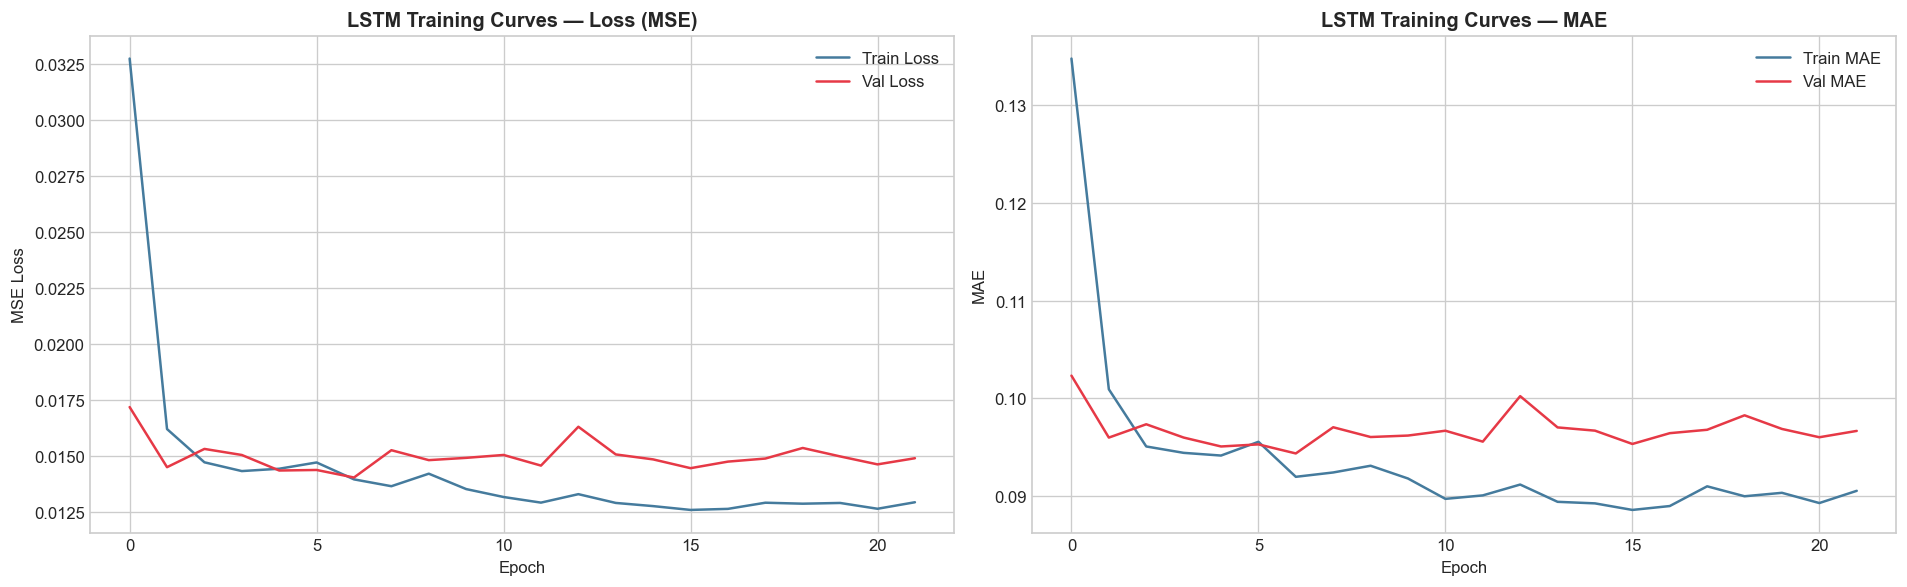


LSTM Results (Lagos):
  RMSE : 0.4700 kWh/m2/day
  MAE  : 0.3716 kWh/m2/day
  R2   : 0.4649


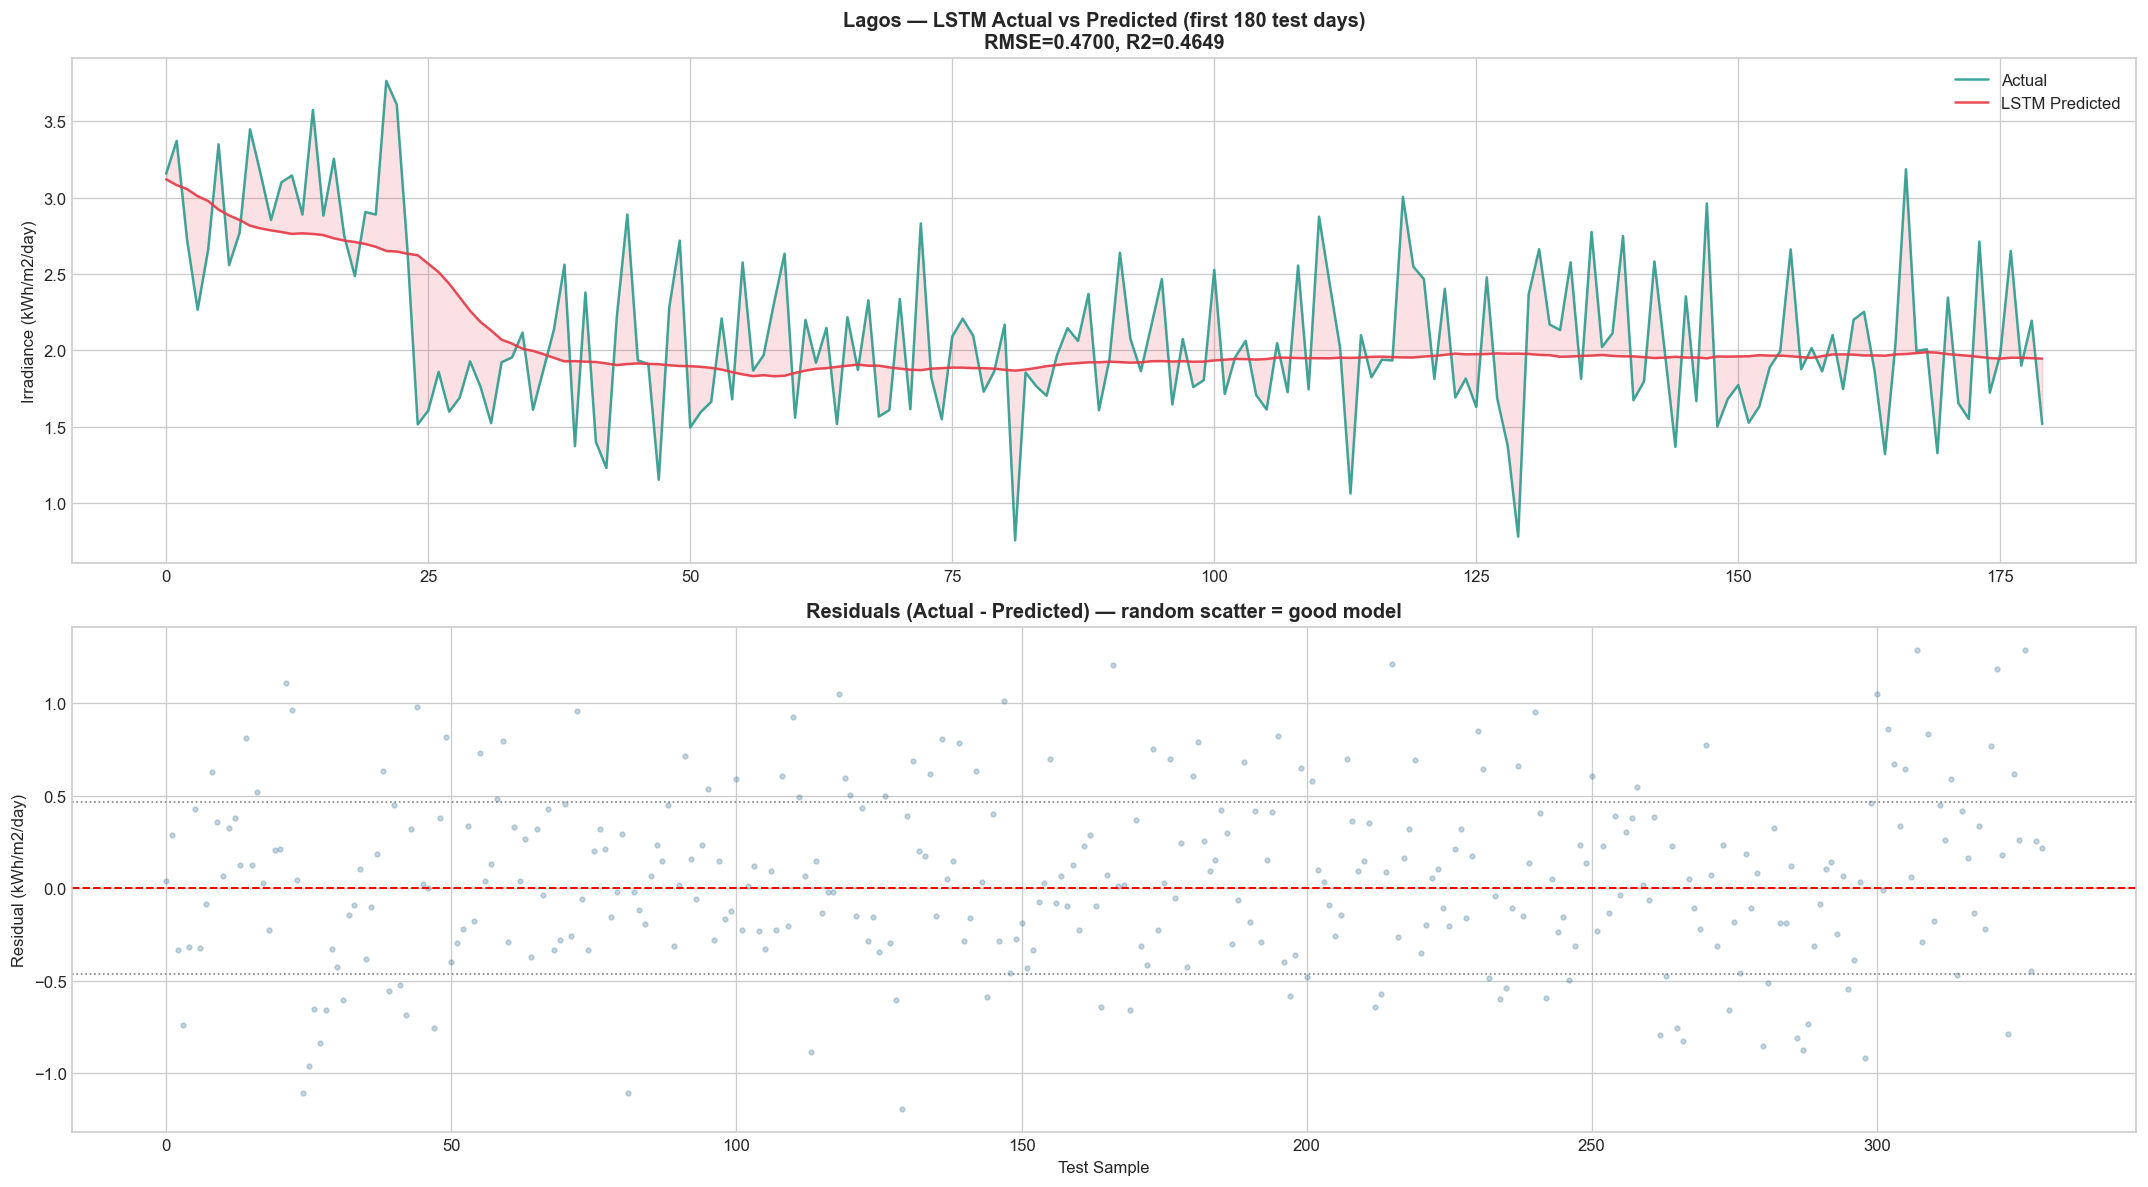

In [15]:
# ─────────────────────────────────────────────────────────────
# LSTM EVALUATION
# ─────────────────────────────────────────────────────────────

# ── Training curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history.history["loss"],     label="Train Loss", color="#457B9D")
axes[0].plot(history.history["val_loss"], label="Val Loss",   color="#E63946")
axes[0].set_title("LSTM Training Curves — Loss (MSE)", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()

axes[1].plot(history.history["mae"],     label="Train MAE", color="#457B9D")
axes[1].plot(history.history["val_mae"], label="Val MAE",   color="#E63946")
axes[1].set_title("LSTM Training Curves — MAE", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/18_lstm_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Predictions on test set ───────────────────────────────────
y_pred_lstm_scaled = lstm_model.predict(X_test_lstm, verbose=0).flatten()

# Inverse transform — bring predictions back to original scale
# We need to reconstruct a full array to inverse_transform correctly
def inverse_target(scaler, values, n_features, target_idx=0):
    dummy = np.zeros((len(values), n_features))
    dummy[:, target_idx] = values
    return scaler.inverse_transform(dummy)[:, target_idx]

y_pred_lstm = inverse_target(scaler, y_pred_lstm_scaled, len(LSTM_FEATURES))
y_test_lstm_orig = inverse_target(scaler, y_test_lstm, len(LSTM_FEATURES))

rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm_orig, y_pred_lstm))
mae_lstm  = mean_absolute_error(y_test_lstm_orig, y_pred_lstm)
r2_lstm   = r2_score(y_test_lstm_orig, y_pred_lstm)

print("\nLSTM Results (Lagos):")
print(f"  RMSE : {rmse_lstm:.4f} kWh/m2/day")
print(f"  MAE  : {mae_lstm:.4f} kWh/m2/day")
print(f"  R2   : {r2_lstm:.4f}")

# ── Actual vs Predicted plot ──────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=False)

n_plot = 180
axes[0].plot(range(n_plot), y_test_lstm_orig[:n_plot],
             color="#2A9D8F", linewidth=1.5, label="Actual", alpha=0.9)
axes[0].plot(range(n_plot), y_pred_lstm[:n_plot],
             color="#E63946", linewidth=1.5, label="LSTM Predicted", alpha=0.9)
axes[0].fill_between(range(n_plot),
    y_test_lstm_orig[:n_plot], y_pred_lstm[:n_plot],
    alpha=0.15, color="#E63946")
axes[0].set_title(
    f"Lagos — LSTM Actual vs Predicted (first 180 test days)\n"
    f"RMSE={rmse_lstm:.4f}, R2={r2_lstm:.4f}",
    fontweight="bold"
)
axes[0].set_ylabel("Irradiance (kWh/m2/day)")
axes[0].legend()

# Residuals
residuals = y_test_lstm_orig - y_pred_lstm
axes[1].scatter(range(len(residuals)), residuals, alpha=0.3, s=8, color="#457B9D")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.2)
axes[1].axhline(residuals.std(), color="gray", linestyle=":", linewidth=1)
axes[1].axhline(-residuals.std(), color="gray", linestyle=":", linewidth=1)
axes[1].set_title("Residuals (Actual - Predicted) — random scatter = good model",
    fontweight="bold")
axes[1].set_xlabel("Test Sample")
axes[1].set_ylabel("Residual (kWh/m2/day)")

plt.tight_layout()
plt.savefig("../data/processed/19_lstm_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

  MODEL COMPARISON
           RMSE     MAE      R2
Model                          
XGBoost  0.4301  0.3422  0.8877
LSTM     0.4700  0.3716  0.4649
  Winner (RMSE): XGBoost
  Winner (R2):   XGBoost


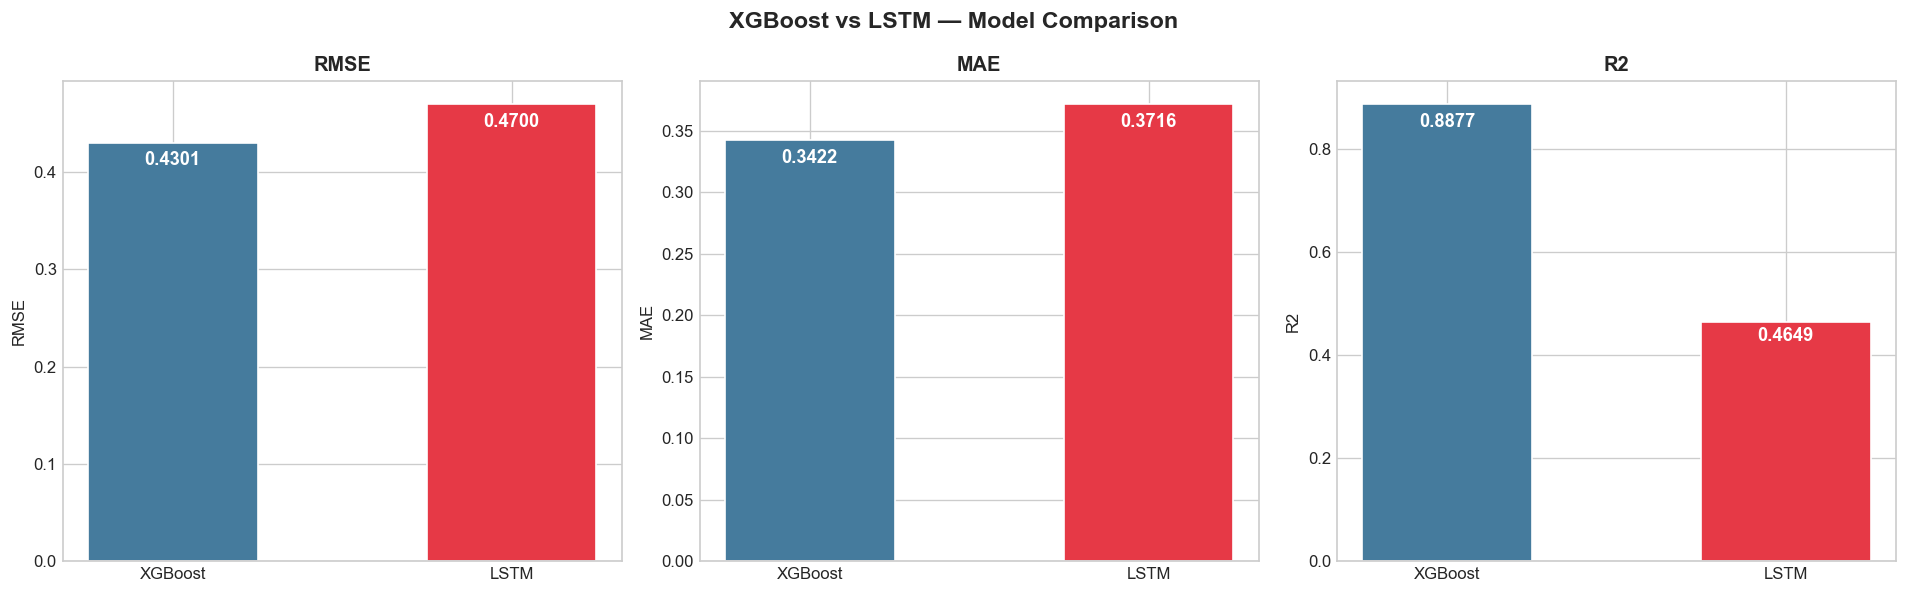

In [16]:
# ─────────────────────────────────────────────────────────────
# MODEL COMPARISON — XGBoost vs LSTM
# ─────────────────────────────────────────────────────────────

results = pd.DataFrame({
    "Model": ["XGBoost", "LSTM"],
    "RMSE":  [rmse_xgb, rmse_lstm],
    "MAE":   [mae_xgb,  mae_lstm],
    "R2":    [r2_xgb,   r2_lstm],
}).set_index("Model").round(4)

print("=" * 45)
print("  MODEL COMPARISON")
print("=" * 45)
print(results.to_string())
print("=" * 45)
print(f"  Winner (RMSE): {results['RMSE'].idxmin()}")
print(f"  Winner (R2):   {results['R2'].idxmax()}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["RMSE", "MAE", "R2"]
colors  = ["#457B9D", "#E63946"]

for ax, metric in zip(axes, metrics):
    vals = results[metric].values
    bars = ax.bar(results.index, vals, color=colors, edgecolor="white", width=0.5)
    ax.set_title(f"{metric}", fontweight="bold")
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val * 0.98,
                f"{val:.4f}", ha="center", va="top", fontsize=11,
                fontweight="bold", color="white")

plt.suptitle("XGBoost vs LSTM — Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/20_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# ─────────────────────────────────────────────────────────────
# SAVE MODELS
# ─────────────────────────────────────────────────────────────
# We save every artifact needed to run predictions in Streamlit:
#   - XGBoost model (.json)
#   - LSTM model (.keras)
#   - Scaler (.pkl) — must use SAME scaler at inference time
#   - Label encoders (.pkl) — needed to encode city/zone at inference

# XGBoost
xgb_model.save_model("../models/xgboost_solar.json")
print("Saved: models/xgboost_solar.json")

# LSTM
lstm_model.save("../models/lstm_solar_lagos.keras")
print("Saved: models/lstm_solar_lagos.keras")

# Scaler & encoders
joblib.dump(scaler,      "../models/lstm_scaler_lagos.pkl")
joblib.dump(le_city,     "../models/label_encoder_city.pkl")
joblib.dump(le_zone,     "../models/label_encoder_zone.pkl")
joblib.dump(FEATURE_COLS,"../models/xgb_feature_cols.pkl")
joblib.dump(LSTM_FEATURES,"../models/lstm_feature_cols.pkl")
print("Saved: scalers and encoders")

print("\nAll model artifacts saved to models/")

Saved: models/xgboost_solar.json
Saved: models/lstm_solar_lagos.keras
Saved: scalers and encoders

All model artifacts saved to models/


In [18]:
print("=" * 60)
print("  PHASE 4 KEY FINDINGS — Solar Forecasting")
print("=" * 60)
print(f"""
1. FEATURE ENGINEERING WAS CRITICAL
   Lag features (irr_lag_1, irr_lag_7) and rolling means
   were the most important XGBoost features — confirming
   that yesterday's irradiance strongly predicts today's.

2. XGBOOST BASELINE PERFORMANCE
   RMSE: {rmse_xgb:.4f} kWh/m2/day
   R2:   {r2_xgb:.4f}
   Trained on all 19 cities simultaneously.
   Fast to train (<30 seconds), easy to deploy.

3. LSTM PERFORMANCE (Lagos)
   RMSE: {rmse_lstm:.4f} kWh/m2/day
   R2:   {r2_lstm:.4f}
   Trained on a single city with 30-day look-back window.
   Captures seasonal patterns that XGBoost cannot.

4. CHRONOLOGICAL SPLIT IS NON-NEGOTIABLE
   Random split would cause data leakage in time series.
   Always split by date: train on past, test on future.

5. WHAT GOES INTO THE STREAMLIT APP:
   - XGBoost model for multi-city fast predictions
   - LSTM model for detailed city-specific forecasting
   - Both models served with saved scalers and encoders
""")
print("=" * 60)

  PHASE 4 KEY FINDINGS — Solar Forecasting

1. FEATURE ENGINEERING WAS CRITICAL
   Lag features (irr_lag_1, irr_lag_7) and rolling means
   were the most important XGBoost features — confirming
   that yesterday's irradiance strongly predicts today's.

2. XGBOOST BASELINE PERFORMANCE
   RMSE: 0.4301 kWh/m2/day
   R2:   0.8877
   Trained on all 19 cities simultaneously.
   Fast to train (<30 seconds), easy to deploy.

3. LSTM PERFORMANCE (Lagos)
   RMSE: 0.4700 kWh/m2/day
   R2:   0.4649
   Trained on a single city with 30-day look-back window.
   Captures seasonal patterns that XGBoost cannot.

4. CHRONOLOGICAL SPLIT IS NON-NEGOTIABLE
   Random split would cause data leakage in time series.
   Always split by date: train on past, test on future.

5. WHAT GOES INTO THE STREAMLIT APP:
   - XGBoost model for multi-city fast predictions
   - LSTM model for detailed city-specific forecasting
   - Both models served with saved scalers and encoders

